# 🧮 unitary
**Obtiene y visualiza la matriz unitaria de un circuito cuántico.**

Usa `qiskit.quantum_info.Operator` para extraer la matriz $U \in \mathbb{C}^{2^n \times 2^n}$
correspondiente a cualquier `QuantumCircuit`.

> ⚠️ **Convención Qiskit (little-endian)**: `q[0]` es el bit *menos* significativo.
> La fila/columna $k$ corresponde al estado base $|k\rangle$ leído de derecha a izquierda.
>
> ⚠️ El circuito **no puede tener mediciones** antes de calcular la unitaria.
> Usa `remove_final_measurements()` si es necesario.

## 📦 1. Instalación de dependencias

In [1]:
try:
    import qiskit
    print(f"✅ Qiskit {qiskit.__version__} ya instalado")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "qiskit", "qiskit-aer", "pylatexenc", "-q"])
    print("✅ Qiskit instalado correctamente")

✅ Qiskit 2.4.1 ya instalado


## 📚 2. Imports

In [2]:
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import (
    RZGate, RYGate, XGate, CXGate, HGate, ZGate, SGate, TGate,
)

print("✅ Imports OK")

✅ Imports OK


## 🔧 3. Helpers: obtener y mostrar la unitaria

### `get_unitary(circuit)`
Devuelve la matriz como `np.ndarray` complejo, eliminando mediciones si existen.

### `print_unitary(U)`
Imprime la matriz en formato tabla, mostrando módulo y fase de cada elemento.

### `plot_unitary(U)`
Grafica la matriz como un heatmap de módulo (amplitud) y otro de fase.

In [3]:
def get_unitary(circuit: QuantumCircuit) -> np.ndarray:
    """
    Extrae la matriz unitaria de un QuantumCircuit.

    - Elimina mediciones finales automáticamente.
    - Retorna np.ndarray de forma (2^n, 2^n) con dtype complex128.
    - Convención Qiskit: q[0] es el bit menos significativo (little-endian).
    """
    qc = circuit.copy()
    qc.remove_final_measurements()
    return Operator(qc).data


def _fmt(z: complex) -> str:
    """Formatea un número complejo como 'modulo∠fase°'."""
    mod   = abs(z)
    phase = math.degrees(math.atan2(z.imag, z.real))
    if mod < 1e-10:
        return "   0         "
    return f"{mod:+.4f}∠{phase:+7.2f}°"


def print_unitary(U: np.ndarray, precision: int = 4) -> None:
    """
    Imprime la unitaria en consola.

    Parámetros
    ----------
    U         : matriz unitaria (output de get_unitary)
    precision : decimales para la parte real/imaginaria
    """
    n = U.shape[0]
    n_qubits = int(math.log2(n))
    labels   = [f"|{i:0{n_qubits}b}⟩" for i in range(n)]

    header = "         " + "  ".join(f"{l:^15}" for l in labels)
    print(header)
    print("─" * len(header))

    for i, row in enumerate(U):
        row_str = "  ".join(_fmt(z) for z in row)
        print(f"{labels[i]}   {row_str}")


def plot_unitary(U: np.ndarray, title: str = "Matriz Unitaria") -> None:
    """
    Visualiza la unitaria con dos heatmaps: módulo y fase.

    - Panel izquierdo : módulo |U_ij|   (colormap viridis, rango [0, 1])
    - Panel derecho   : fase arg(U_ij)  (colormap hsv, rango [-π, π])
    """
    n        = U.shape[0]
    n_qubits = int(math.log2(n))
    labels   = [f"|{i:0{n_qubits}b}⟩" for i in range(n)]

    mod   = np.abs(U)
    phase = np.angle(U)            # radianes en [-π, π]

    fig, axes = plt.subplots(1, 2, figsize=(max(8, n * 1.2), max(4, n * 0.9)))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── Módulo ───────────────────────────────────────────────────────────────
    im0 = axes[0].imshow(mod, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    axes[0].set_title("Módulo  |U|")
    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(labels)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    for i in range(n):
        for j in range(n):
            v = mod[i, j]
            if v > 1e-6:
                axes[0].text(j, i, f"{v:.2f}",
                             ha="center", va="center", fontsize=8,
                             color="white" if v < 0.7 else "black")

    # ── Fase ─────────────────────────────────────────────────────────────────
    im1 = axes[1].imshow(phase, cmap="hsv", vmin=-math.pi, vmax=math.pi, aspect="auto")
    axes[1].set_title("Fase  arg(U)  [rad]")
    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(labels, rotation=45, ha="right")
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(labels)
    cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_ticks([-math.pi, -math.pi/2, 0, math.pi/2, math.pi])
    cbar1.set_ticklabels(["-π", "-π/2", "0", "π/2", "π"])

    for i in range(n):
        for j in range(n):
            if mod[i, j] > 1e-6:
                axes[1].text(j, i, f"{phase[i,j]:.2f}",
                             ha="center", va="center", fontsize=8, color="black")

    plt.tight_layout()
    plt.show()


print("✅ Helpers definidos")

✅ Helpers definidos


## 📥 4. Parser json2quantum
*(copiado de `json2quantum.ipynb` para poder cargar circuitos desde archivo)*

In [4]:
GATE_MAP: dict = {
    "X":    lambda p: XGate(),
    "H":    lambda p: HGate(),
    "Z":    lambda p: ZGate(),
    "S":    lambda p: SGate(),
    "T":    lambda p: TGate(),
    "Rz":   lambda p: RZGate(p),
    "RZ":   lambda p: RZGate(p),
    "Ry":   lambda p: RYGate(p),
    "RY":   lambda p: RYGate(p),
    "CNOT": lambda p: CXGate(),
    "CX":   lambda p: CXGate(),
}


def _resolve_control(c) -> int:
    if isinstance(c, int):
        return c
    if isinstance(c, dict):
        return c["qubit"]
    raise ValueError(f"Formato de control no reconocido: {c!r}")


def parse_json_to_circuit(json_data: dict) -> QuantumCircuit:
    n_qubits   = json_data["qubits"]
    operations = json_data["operations"]
    level      = json_data.get("level", "?")

    qr = QuantumRegister(n_qubits, name="q")
    cr = ClassicalRegister(n_qubits, name="c")
    qc = QuantumCircuit(qr, cr, name=f"nivel{level}")

    for op in operations:
        gate_def  = op["gate"]
        name      = gate_def["name"]
        parameter = gate_def.get("parameter", None)
        controls  = gate_def.get("controls", [])
        target    = gate_def["target"]

        gate = GATE_MAP[name](parameter).to_mutable()
        gate.label = gate_def.get("label", name)

        control_indices = [_resolve_control(c) for c in controls]
        all_qubits      = [qr[c] for c in control_indices] + [qr[target]]
        qc.append(gate, all_qubits)

    qc.measure(qr, cr)
    return qc


print("✅ Parser listo")

✅ Parser listo


---
## 🧪 5. Demos

### 5a — Bell State `|Φ+⟩`
Matriz 4×4. La unitaria del Bell State es la del CNOT·(H⊗I).

In [5]:
qc_bell = QuantumCircuit(2, name="bell")
qc_bell.h(0)
qc_bell.cx(0, 1)

U_bell = get_unitary(qc_bell)

print("🔔 Bell State — Matriz unitaria (numpy):")
print(np.round(U_bell, 4))
print()

print("🔔 Bell State — Tabla módulo∠fase:")
print_unitary(U_bell)
print()

# Verificar que es unitaria: U†·U ≈ I
identity_check = np.allclose(U_bell @ U_bell.conj().T, np.eye(4))
print(f"✅ U†·U ≈ I: {identity_check}")

🔔 Bell State — Matriz unitaria (numpy):
[[ 0.7071+0.j  0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j -0.7071+0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j  0.    +0.j  0.    +0.j]]

🔔 Bell State — Tabla módulo∠fase:
              |00⟩             |01⟩             |10⟩             |11⟩      
───────────────────────────────────────────────────────────────────────────
|00⟩   +0.7071∠  +0.00°  +0.7071∠  +0.00°     0              0         
|01⟩      0              0           +0.7071∠  +0.00°  +0.7071∠+180.00°
|10⟩      0              0           +0.7071∠  +0.00°  +0.7071∠  +0.00°
|11⟩   +0.7071∠  +0.00°  +0.7071∠+180.00°     0              0         

✅ U†·U ≈ I: True


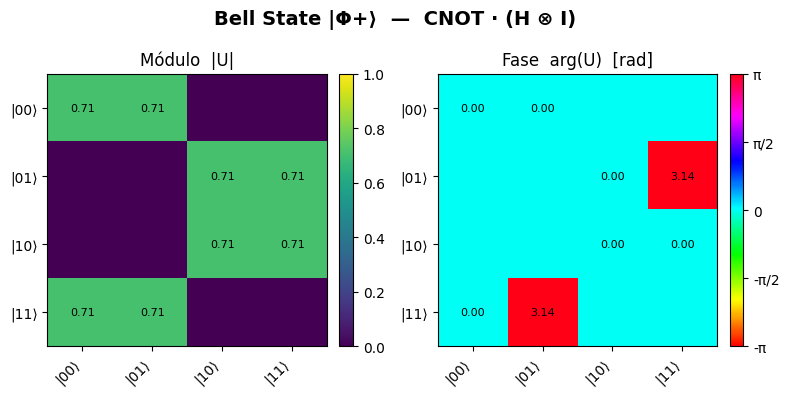

In [6]:
plot_unitary(U_bell, title="Bell State |Φ+⟩  —  CNOT · (H ⊗ I)")

### 5b — Compuertas de 1 qubit: H, X, Z, S, T, Rz(π/4), Ry(π/3)

In [7]:
single_gates = {
    "H":        lambda qc: qc.h(0),
    "X":        lambda qc: qc.x(0),
    "Z":        lambda qc: qc.z(0),
    "S":        lambda qc: qc.s(0),
    "T":        lambda qc: qc.t(0),
    "Rz(π/4)": lambda qc: qc.rz(math.pi / 4, 0),
    "Ry(π/3)": lambda qc: qc.ry(math.pi / 3, 0),
}

for gate_name, apply in single_gates.items():
    qc = QuantumCircuit(1)
    apply(qc)
    U = get_unitary(qc)
    print(f"── {gate_name} ──────────────────────")
    print(np.round(U, 4))
    print()

── H ──────────────────────
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

── X ──────────────────────
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

── Z ──────────────────────
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

── S ──────────────────────
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

── T ──────────────────────
[[1.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.7071+0.7071j]]

── Rz(π/4) ──────────────────────
[[0.9239-0.3827j 0.    +0.j    ]
 [0.    +0.j     0.9239+0.3827j]]

── Ry(π/3) ──────────────────────
[[ 0.866+0.j -0.5  +0.j]
 [ 0.5  +0.j  0.866+0.j]]



### 5c — Desde un archivo JSON (json2quantum)
Carga `bell_recovered.json` y obtiene su unitaria.

In [8]:
JSON_FILE = "bell_recovered.json"   # ← cambia aquí para otro nivel

with open(JSON_FILE, "r") as f:
    data = json.load(f)

qc_from_json = parse_json_to_circuit(data)
U_from_json  = get_unitary(qc_from_json)

print(f"📄 Unitaria de '{JSON_FILE}':")
print(np.round(U_from_json, 4))
print()

# Comparar con la unitaria calculada directamente
print(f"🔍 ¿Igual a U_bell? {np.allclose(U_from_json, U_bell, atol=1e-8)}")

📄 Unitaria de 'bell_recovered.json':
[[ 0.7071+0.j  0.7071+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j -0.7071+0.j]
 [ 0.    +0.j  0.    +0.j  0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j  0.    +0.j  0.    +0.j]]

🔍 ¿Igual a U_bell? True


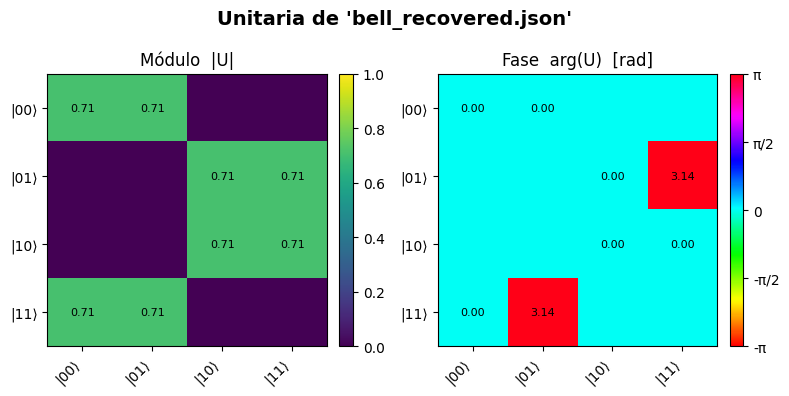

In [9]:
plot_unitary(U_from_json, title=f"Unitaria de '{JSON_FILE}'")

### 5d — `nivel6.json` (4 qubits → matriz 16×16)

In [23]:
with open("nivel6.json", "r") as f:
    data6 = json.load(f)

qc6   = parse_json_to_circuit(data6)
U6    = get_unitary(qc6)

print(f"⚛️  nivel6.json — {U6.shape[0]}×{U6.shape[1]} unitaria")
print("Módulos (valores ~0 truncados a 0):")
print(np.round(U6, 4))
#print(np.where(np.abs(U6) < 1e-8, 0, np.round(np.abs(U6), 4)))

⚛️  nivel6.json — 16×16 unitaria
Módulos (valores ~0 truncados a 0):
[[ 0.6533-0.2706j  0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.6533+0.2706j  0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.6533-0.2706j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j     -0.6533-0.2706j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.6533-0.2706j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.6533+0.2706j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.6533-0.2706j  0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j     -0.6533-0.2706j  0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.   

In [32]:
dim=U6.shape[0]
n_qubits = int(np.log2(dim))
qc = QuantumCircuit(n_qubits)

qc.unitary(U6, range(n_qubits))
qc.draw()


┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1         ├
     │  Unitary │
q_2: ┤2         ├
     │          │
q_3: ┤3         ├
     └──────────┘

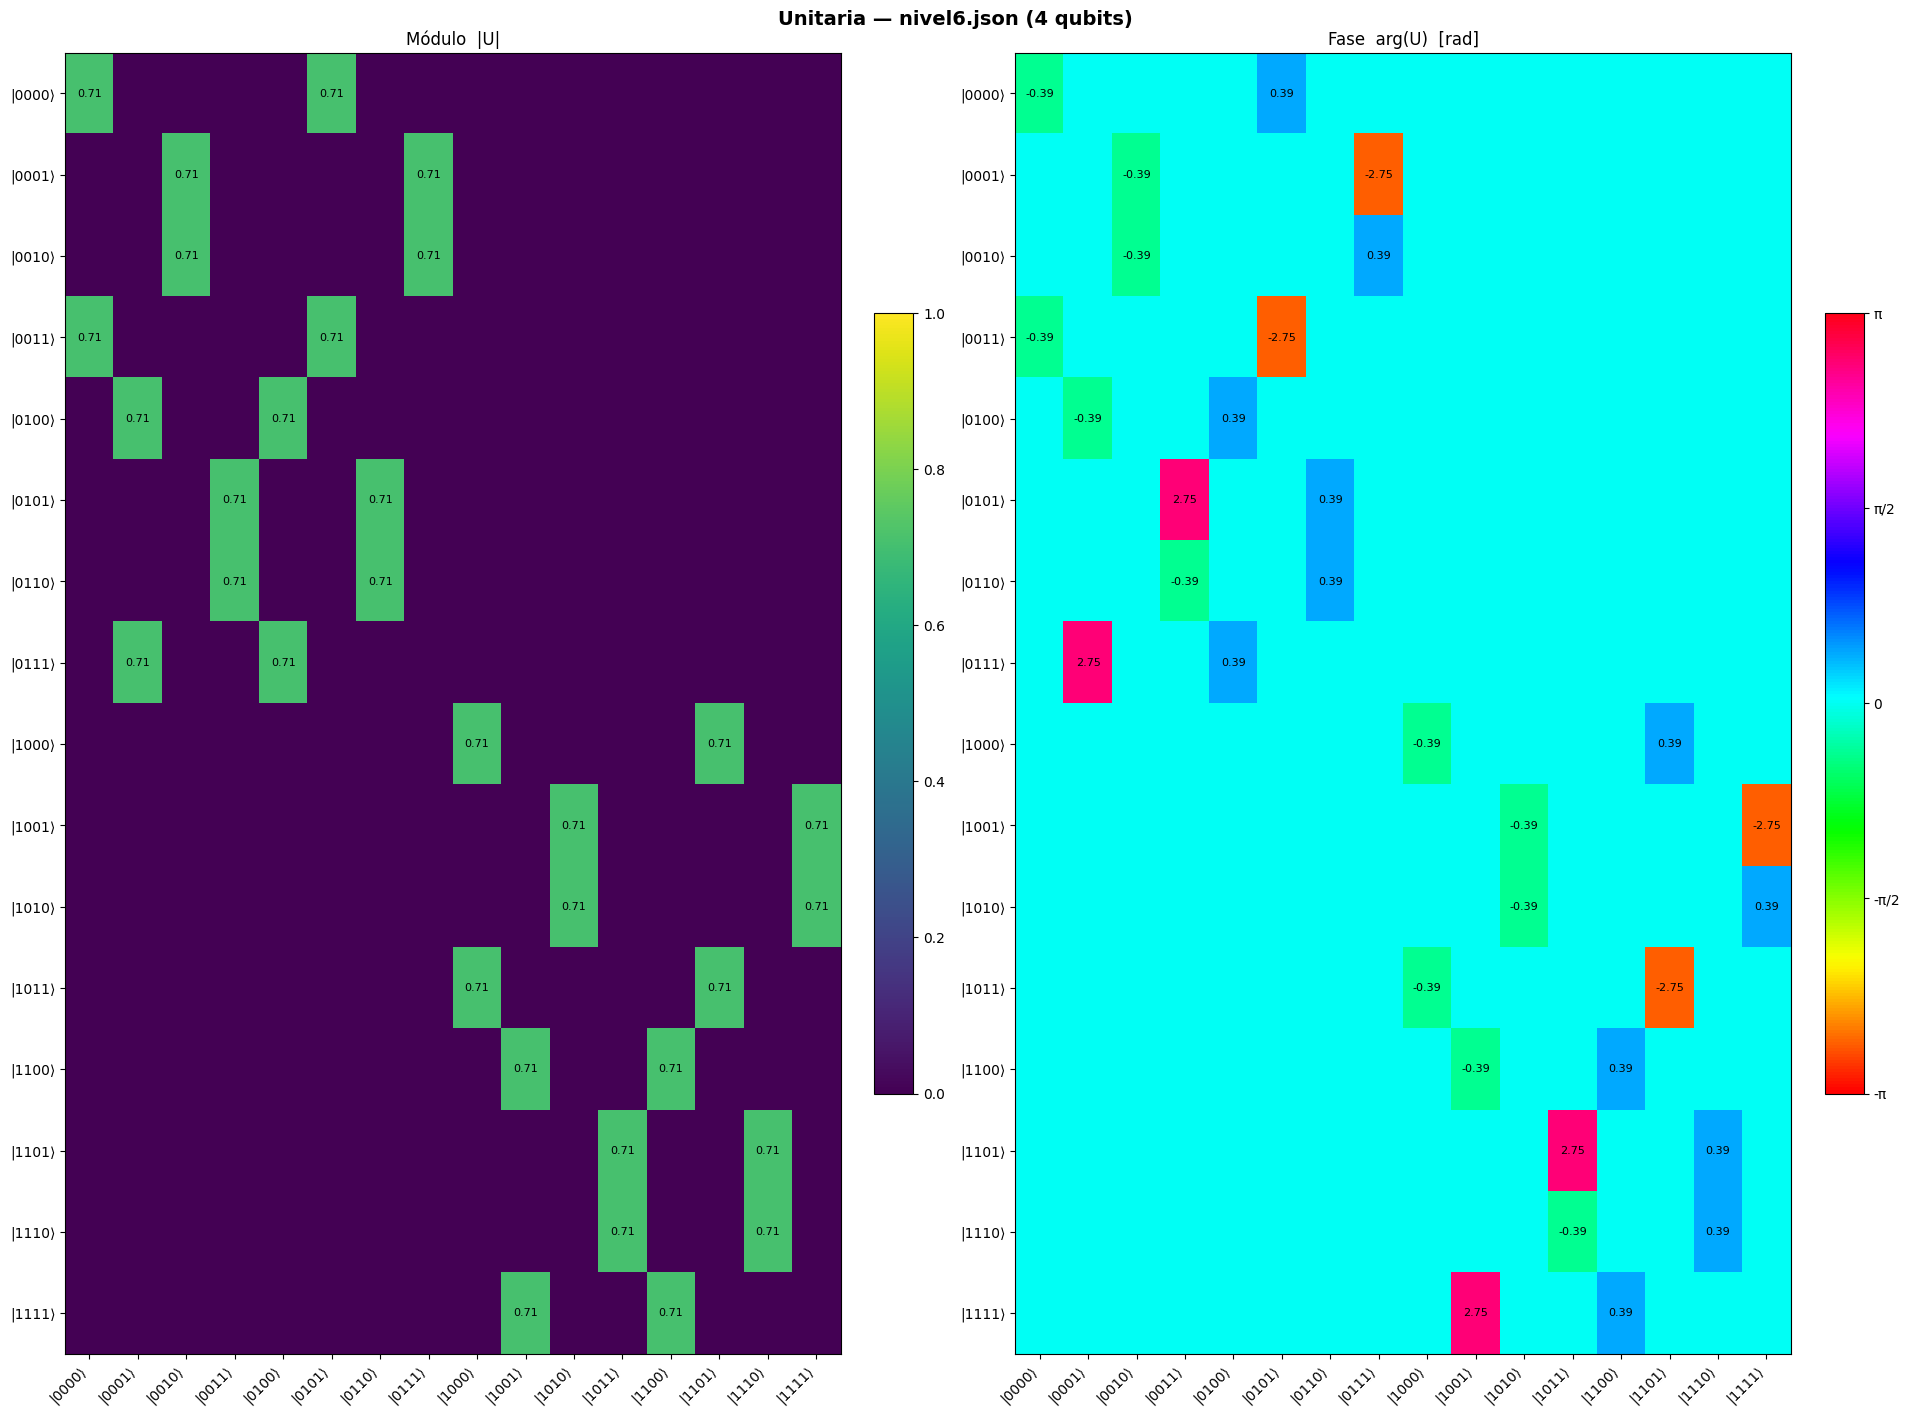

In [34]:
plot_unitary(U6, title="Unitaria — nivel6.json (4 qubits)")

---
## 🛠️ 6. Utilidades extra

### `are_equivalent(qc_a, qc_b)`
Compara dos circuitos por su unitaria (útil para verificar optimizaciones).

### `unitary_to_json(U, path)`
Exporta la matriz a JSON (real e imaginaria separadas).

In [12]:
def are_equivalent(qc_a: QuantumCircuit, qc_b: QuantumCircuit, atol: float = 1e-8) -> bool:
    """
    Devuelve True si los dos circuitos implementan la misma unitaria
    (salvo fase global).
    """
    Ua = get_unitary(qc_a)
    Ub = get_unitary(qc_b)
    if Ua.shape != Ub.shape:
        return False
    # Eliminar fase global: comparar Ua con e^{iθ}·Ub
    # Si son equivalentes salvo fase, Ua†·Ub es proporcional a la identidad
    product = Ua.conj().T @ Ub
    diag    = np.diag(product)
    if not np.allclose(np.abs(diag), 1.0, atol=atol):
        return False
    phase = diag[0]
    return np.allclose(product, phase * np.eye(Ua.shape[0]), atol=atol)


def unitary_to_json(U: np.ndarray, path: str | Path) -> Path:
    """
    Exporta la matriz unitaria a JSON alternando partes real e imaginaria.

    Formato::

        [
          [[a11_real, a11_imag], [a12_real, a12_imag]],
          [[a21_real, a21_imag], [a22_real, a22_imag]]
        ]
    """
    output = Path(path)
    payload = np.stack((np.round(U.real, 10), np.round(U.imag, 10)), axis=-1).tolist()
    output.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return output
print("✅ Utilidades definidas")

✅ Utilidades definidas


In [13]:
# ── Demo are_equivalent ──────────────────────────────────────────────────────
# CNOT·(H⊗I) == Bell circuit?
qc_a = QuantumCircuit(2); qc_a.h(0); qc_a.cx(0, 1)
qc_b = QuantumCircuit(2); qc_b.h(0); qc_b.cx(0, 1)  # circuito idéntico
qc_c = QuantumCircuit(2); qc_c.cx(0, 1); qc_c.h(0)  # orden distinto

print(f"qc_a == qc_b (idénticos):      {are_equivalent(qc_a, qc_b)}")
print(f"qc_a == qc_c (orden distinto): {are_equivalent(qc_a, qc_c)}")

# ── Demo unitary_to_json ─────────────────────────────────────────────────────
out = unitary_to_json(U_bell, "bell_unitary.json")
print(f"\n💾 Unitaria exportada a: {out.resolve()}")

qc_a == qc_b (idénticos):      True
qc_a == qc_c (orden distinto): False

💾 Unitaria exportada a: C:\Users\palob\Program\Quantum\json2quantum\bell_unitary.json
